In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df = pd.read_csv("placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [2]:
df.shape

(200, 2)

Text(0.5, 1.0, 'Placement Data')

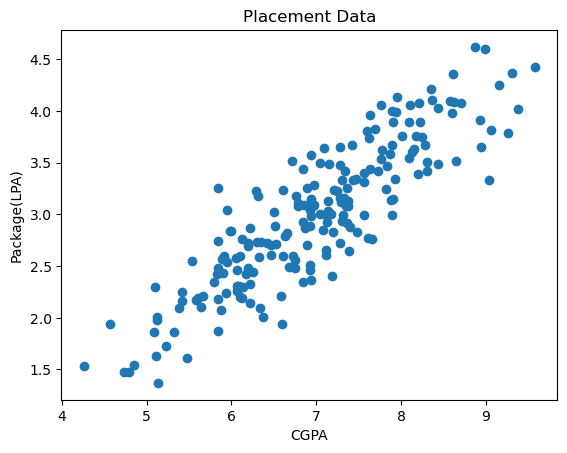

In [4]:
plt.scatter(df.iloc[:,0],df.iloc[:,1])
plt.xlabel("CGPA")
plt.ylabel("Package(LPA)")
plt.title("Placement Data")

In [7]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [8]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
X_train.shape

(160, 1)

In [11]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0.5, 1.0, 'Placement Data with Regression Line')

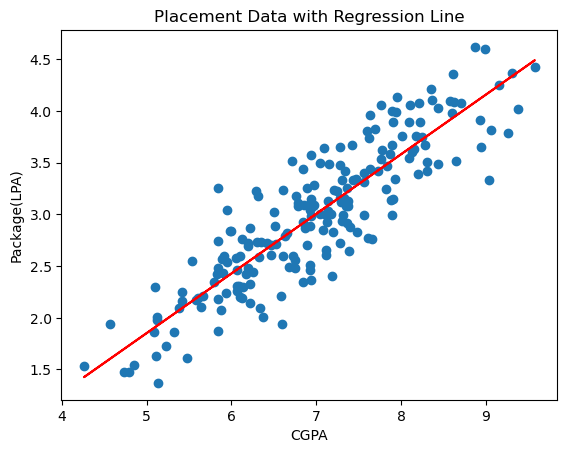

In [12]:
plt.scatter(df.iloc[:,0],df.iloc[:,1])
plt.plot(X_train,lr.predict(X_train),color="red")
plt.xlabel("CGPA")
plt.ylabel("Package(LPA)")
plt.title("Placement Data with Regression Line")

In [13]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
y_pred = lr.predict(X_test)
print("MSE=",mean_squared_error(y_test,y_pred))
print("R2 Score=",r2_score(y_test,y_pred))
print("MAE=",mean_absolute_error(y_test,y_pred))
print("RMSE=",np.sqrt(mean_squared_error(y_test,y_pred)))
print("Adjusted R2 Score=",1-(1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

MSE= 0.10221131059334207
R2 Score= 0.7297167943957027
MAE= 0.2552433448620408
RMSE= 0.31970503685951224
Adjusted R2 Score= 0.7226040784587475


In [14]:
new_data = df.copy()
new_data["random_features"] = np.random.random(size=200)
new_data=new_data[["cgpa","random_features","package"]]
new_data.head()

,cgpa,random_features,package
0,6.89,0.571859,3.26
1,5.12,0.783371,1.98
2,7.82,0.336639,3.25
3,7.42,0.710975,3.67
4,6.94,0.510843,3.57


Text(0.5, 1.0, 'Random Features vs Package')

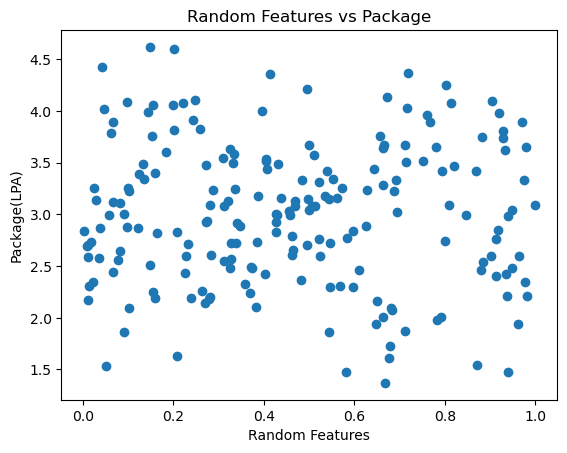

In [16]:
plt.scatter(new_data['random_features'],new_data['package'])
plt.xlabel("Random Features")
plt.ylabel("Package(LPA)")
plt.title("Random Features vs Package")

In [17]:
X = new_data.iloc[:,0:2]
y = new_data.iloc[:,-1]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
lr= LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = lr.predict(X_test)
print("MSE=",mean_squared_error(y_test,y_pred))
print("R2 Score=",r2_score(y_test,y_pred))
print("MAE=",mean_absolute_error(y_test,y_pred))
print("RMSE=",np.sqrt(mean_squared_error(y_test,y_pred)))
print("Adjusted R2 Score=",1-(1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

MSE= 0.10256280295385918
R2 Score= 0.7287873230740408
MAE= 0.2556238864000445
RMSE= 0.32025427858790456
Adjusted R2 Score= 0.7141271783753403
